<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Applied-DL/blob/main/Copy_of_Exercise_10_real_time_noise_rejection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from matplotlib import pyplot as plt
import numpy as np

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, GlobalAveragePooling1D, Activation, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D

You can estimate how fast a network prediction can be calculated by calculating the number of floating point operations performed in the network. This function is a handy tool to do it. Use it like this `print(get_flops(my_model))` where `my_model` is your KERAS neural network model.

In [2]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph
import tensorflow as tf
######################################Calculate FLOPS##########################################
def get_flops(model):
    '''
    Calculate FLOPS
    Parameters
    ----------
    model : tf.keras.Model
        Model for calculating FLOPS.

    Returns
    -------
    flops.total_float_ops : int
        Calculated FLOPS for the model
    '''

    batch_size = 1

    # Fix: Use list() to robustly convert the input shape (which is currently a tuple) to a Python list for concatenation
    # model.inputs[0].shape[1:] is resolving to a tuple like (100,)
    input_shape_list = list(model.inputs[0].shape[1:])

    real_model = tf.function(model).get_concrete_function(tf.TensorSpec([batch_size] + input_shape_list, model.inputs[0].dtype))
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(real_model)

    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

    flops = tf.compat.v1.profiler.profile(
        graph=frozen_func.graph,
        run_meta=run_meta,
        cmd='op',
        options=opts
    )
    return flops.total_float_ops

Downloading the data (1 signal data file and 5 noise data files)

In [3]:
# download data file that contains signal events
if not os.path.exists("trimmed100_data_signal_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=1t-1icmiJ8Nwu1dm_USIc_W13B68QDwqq


Downloading...
From: https://drive.google.com/uc?id=1t-1icmiJ8Nwu1dm_USIc_W13B68QDwqq
To: /content/trimmed100_data_signal_3.6SNR_1ch_0000.npy
100% 80.0M/80.0M [00:00<00:00, 182MB/s]


In [4]:
# download data file that contains noise events
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=14Aff8wf-e1qTQwWU0I-PkrbdbdtS6dei
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0001.npy"):
  !gdown https://drive.google.com/uc?id=1EkhWgOXOvaK74JiWPOxt6DUE4S5NGYrT
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0002.npy"):
  !gdown https://drive.google.com/uc?id=1BSPvbNOJ2kG7p3ImsVekz4jwXUqlhLRd
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0003.npy"):
  !gdown https://drive.google.com/uc?id=1xoTjcJd762XUAP0I7Ukv0y2go6ZwTmIa
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0004.npy"):
  !gdown https://drive.google.com/uc?id=1CAmatsbjLmhefxvoH4fr7O-8pGA5p4KY
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0005.npy"):
  !gdown https://drive.google.com/uc?id=1lX4M1t8W4zg0wVXA4HYUlnFGU3nMYPGx

Downloading...
From: https://drive.google.com/uc?id=14Aff8wf-e1qTQwWU0I-PkrbdbdtS6dei
To: /content/trimmed100_data_noise_3.6SNR_1ch_0000.npy
100% 80.0M/80.0M [00:00<00:00, 258MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EkhWgOXOvaK74JiWPOxt6DUE4S5NGYrT
To: /content/trimmed100_data_noise_3.6SNR_1ch_0001.npy
100% 80.0M/80.0M [00:00<00:00, 129MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BSPvbNOJ2kG7p3ImsVekz4jwXUqlhLRd
To: /content/trimmed100_data_noise_3.6SNR_1ch_0002.npy
100% 80.0M/80.0M [00:00<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xoTjcJd762XUAP0I7Ukv0y2go6ZwTmIa
To: /content/trimmed100_data_noise_3.6SNR_1ch_0003.npy
100% 80.0M/80.0M [00:00<00:00, 156MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CAmatsbjLmhefxvoH4fr7O-8pGA5p4KY
To: /content/trimmed100_data_noise_3.6SNR_1ch_0004.npy
100% 80.0M/80.0M [00:00<00:00, 243MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lX4M1t8W4zg0wVXA4HYUlnFGU3nMYPGx
To: /cont

Load the data into memory and combine it into one array.

In [5]:
# load signal and noise data set into memory
noise = np.load("trimmed100_data_noise_3.6SNR_1ch_0000.npy")
for i in range(1,5):
  noise = np.vstack((noise,np.load(f"trimmed100_data_noise_3.6SNR_1ch_000{i}.npy")))
signal = np.load("trimmed100_data_signal_3.6SNR_1ch_0000.npy")
n_classes = 2

In [6]:
# combine noise and signal data set
x = np.vstack((noise, signal))
print(x.shape)
# in case you want to train a CNN, you need to add an empty dimension to the array
# which you can do via x = np.expand_dims(x, axis=-1)

# define labels. As we have only two categories, we don't use one-hot encoding
# but can just use "0" for noise and "1" for signal.
y = np.ones(len(x))
y[:len(noise)] = 0

(599997, 100)


Currently, the training data first contains all noise events and then only signal events. This is not optimal, especially because Keras will pick the last X% of the data set for the validation data (which would mean we train only on noise and then validate with signal, which does not make much sense). Therefore, we randomly shuffle the dataset. Important: The x and y arrays need to be shuffled identicially as in the code below.

In [7]:
# shuffel the data
shuffle = np.arange(x.shape[0], dtype=int)
np.random.shuffle(shuffle)
x = x[shuffle]
y = y[shuffle]

# to still be able to identify the signal events you can do
smask = y == 1
# then you can get all signal events via `x[smask]`
# and all noise events via `x[~smask]`


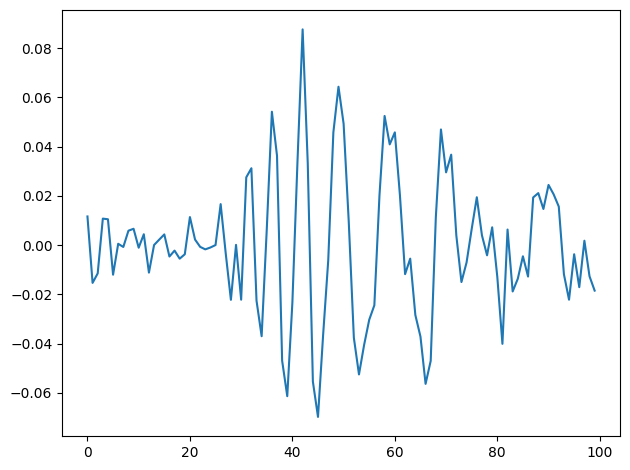

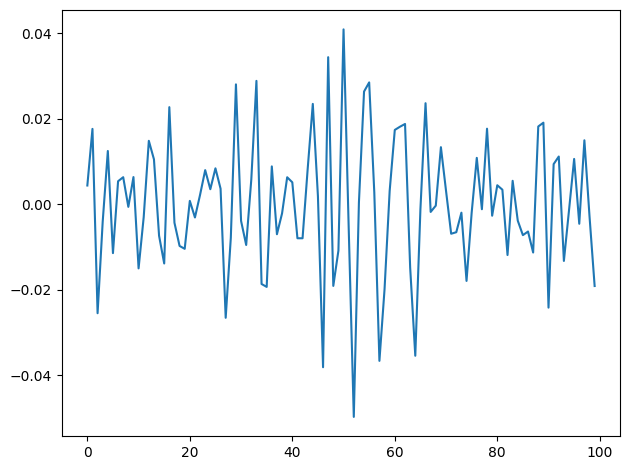

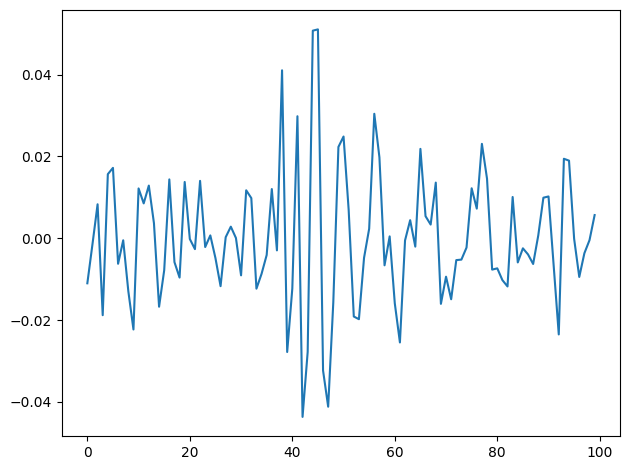

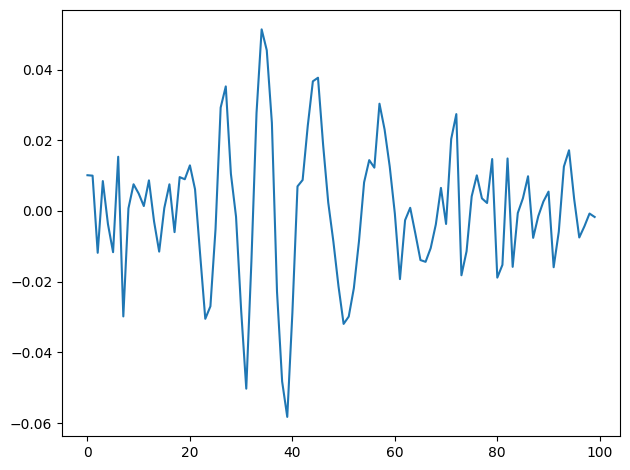

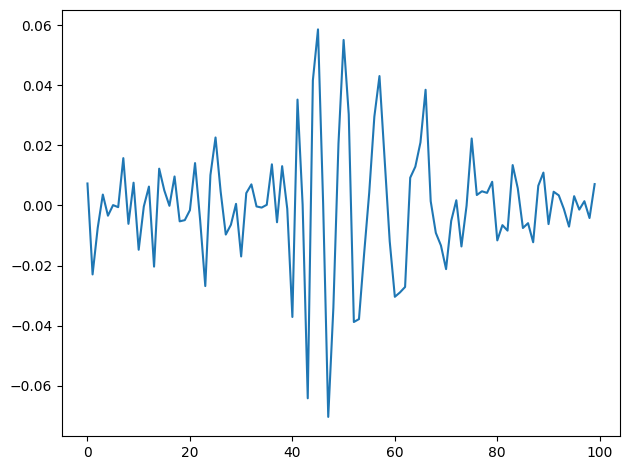

In [8]:
# plot a few signal events
for trace in x[smask][:5]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

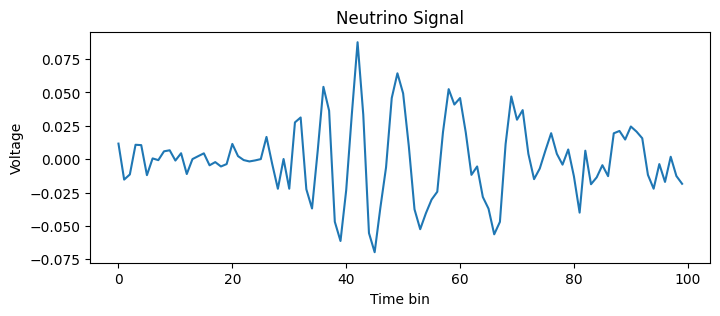

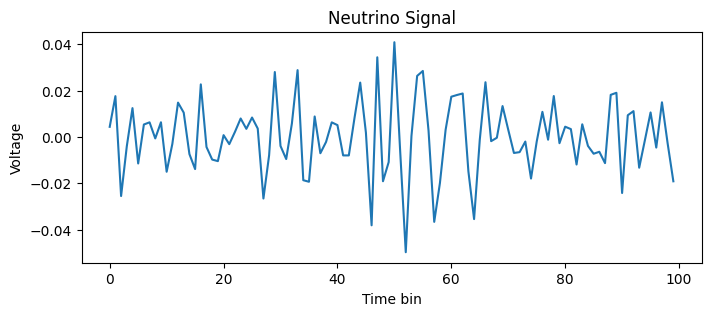

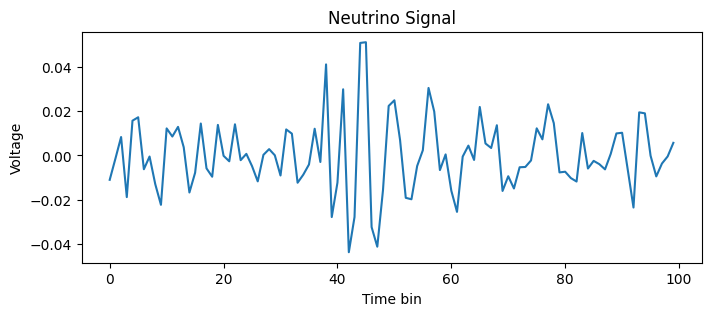

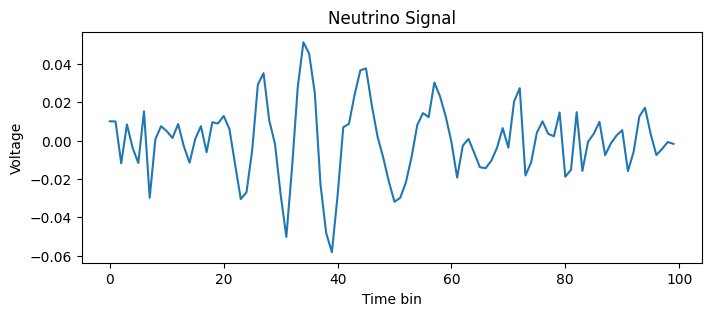

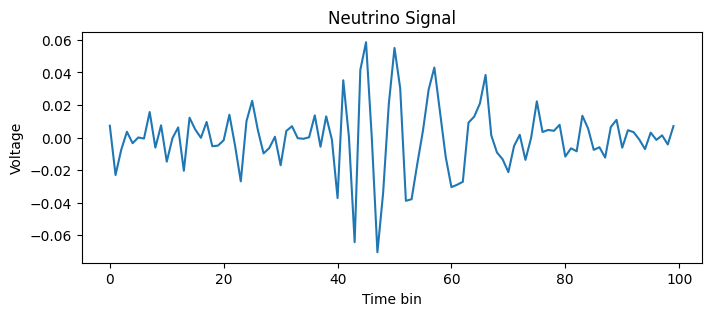

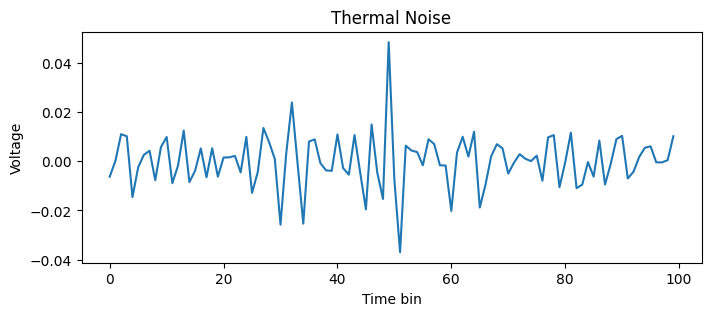

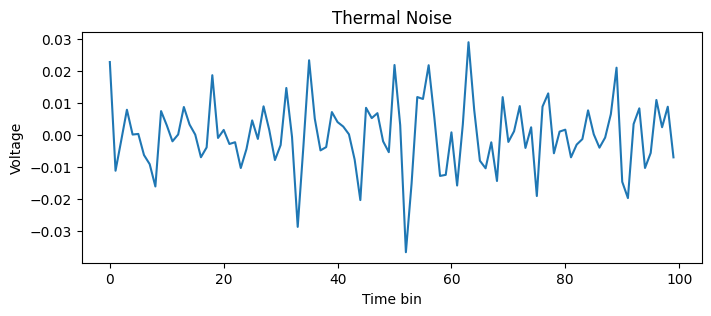

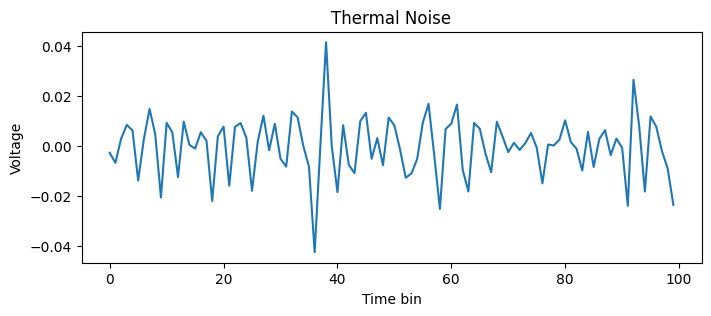

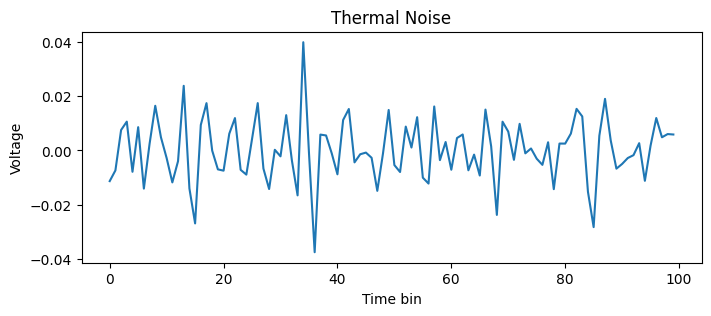

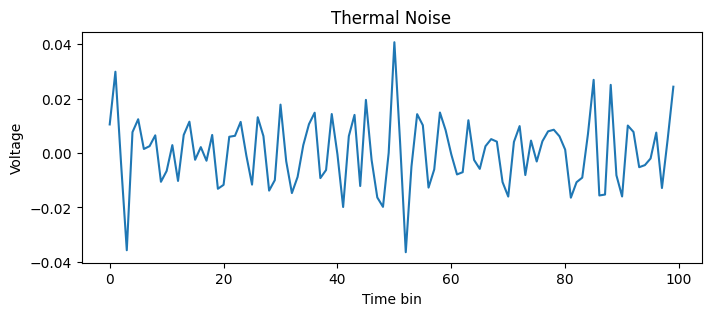

In [9]:
# Plot signal examples
for trace in x[smask][:5]:
    plt.figure(figsize=(8,3))
    plt.plot(trace)
    plt.title("Neutrino Signal")
    plt.xlabel("Time bin")
    plt.ylabel("Voltage")
    plt.show()

# Plot noise examples
for trace in x[~smask][:5]:
    plt.figure(figsize=(8,3))
    plt.plot(trace)
    plt.title("Thermal Noise")
    plt.xlabel("Time bin")
    plt.ylabel("Voltage")
    plt.show()

Noise events appear as random fluctuations around zero, whereas signal events usually contain a localized pulse structure with a larger amplitude.

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
mean = np.mean(x_train)
std = np.std(x_train)

x_train = (x_train - mean)/std
x_val = (x_val - mean)/std

In [12]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(100,)),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=1024,
    verbose=1
)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9364 - loss: 0.2037 - val_accuracy: 0.9888 - val_loss: 0.0381
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9864 - loss: 0.0481 - val_accuracy: 0.9927 - val_loss: 0.0257
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - loss: 0.0366 - val_accuracy: 0.9943 - val_loss: 0.0216
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9910 - loss: 0.0321 - val_accuracy: 0.9944 - val_loss: 0.0203
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9919 - loss: 0.0287 - val_accuracy: 0.9948 - val_loss: 0.0195
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9927 - loss: 0.0266 - val_accuracy: 0.9946 - val_loss: 0.0196
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9929 - loss: 0.0260 - val_accuracy: 0.9952 - val_loss: 0.0181
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9933 - loss: 0.0247 - val_acc

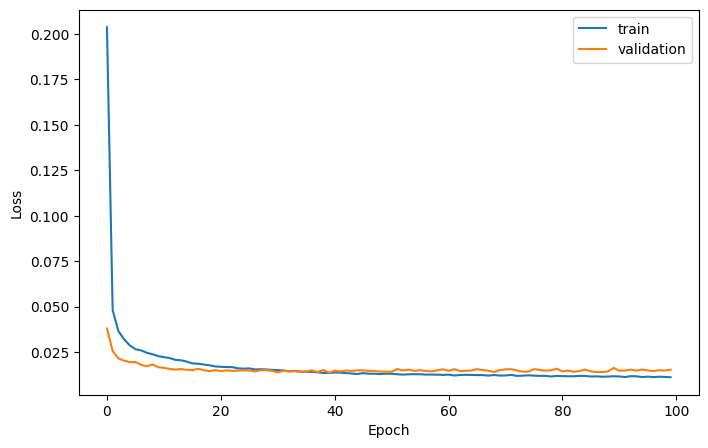

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
pred = model.predict(x_val).flatten()
thresholds = np.linspace(0,1,500)

signal_eff = []
noise_rej = []

signal_mask = y_val == 1
noise_mask = y_val == 0

for thr in thresholds:

    pred_signal = pred > thr

    sig_eff = np.sum(pred_signal[signal_mask]) / np.sum(signal_mask)

    noise_rejection = np.sum(~pred_signal[noise_mask]) / np.sum(noise_mask)

    signal_eff.append(sig_eff)
    noise_rej.append(noise_rejection)

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


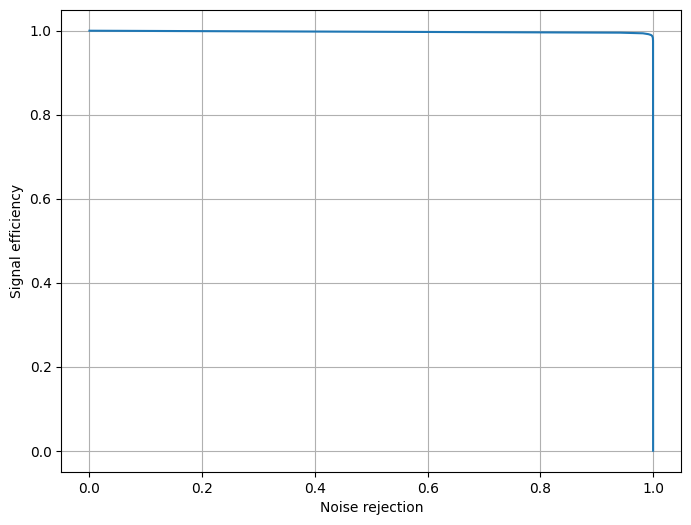

In [17]:
plt.figure(figsize=(8,6))
plt.plot(noise_rej, signal_eff)
plt.xlabel("Noise rejection")
plt.ylabel("Signal efficiency")
plt.grid()
plt.show()

In [18]:
target = np.where(
    (np.array(noise_rej) >= 0.999) &
    (np.array(signal_eff) >= 0.90)
)[0]

if len(target) > 0:
    idx = target[0]
    print("Threshold =", thresholds[idx])
    print("Noise rejection =", noise_rej[idx])
    print("Signal efficiency =", signal_eff[idx])
else:
    print("Target performance not reached")

Threshold = 0.11022044088176351
Noise rejection = 0.9990000099999
Signal efficiency = 0.9858492924646233


In [19]:
flops = get_flops(model)
print("Total FLOPS:", flops)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Total FLOPS: 18065


In [20]:
small_model = Sequential([
    Dense(16, activation='relu', input_shape=(100,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

small_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_small = small_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=1024,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9183 - loss: 0.2806 - val_accuracy: 0.9713 - val_loss: 0.1017
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9782 - loss: 0.0755 - val_accuracy: 0.9823 - val_loss: 0.0616
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9844 - loss: 0.0533 - val_accuracy: 0.9860 - val_loss: 0.0480
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9869 - loss: 0.0444 - val_accuracy: 0.9876 - val_loss: 0.0419
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9882 - loss: 0.0400 - val_accuracy: 0.9888 - val_loss: 0.0392
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9891 - loss: 0.0372 - val_accuracy: 0.9893 - val_loss: 0.0373
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9895 - loss: 0.0357 - val_accuracy: 0.9897 - val_loss: 0.0363
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9900 - loss: 0.0345 - val_accuracy: 0.

In [21]:
small_flops = get_flops(small_model)

print("Optimized model FLOPS:",
      small_flops)

Optimized model FLOPS: 3497


In [22]:
pred_small = small_model.predict(x_val).flatten()

signal_eff_small = []
noise_rej_small = []

for thr in thresholds:

    pred_signal = pred_small > thr

    sig_eff = np.sum(pred_signal[signal_mask]) / np.sum(signal_mask)

    noise_rejection = np.sum(~pred_signal[noise_mask]) / np.sum(noise_mask)

    signal_eff_small.append(sig_eff)
    noise_rej_small.append(noise_rejection)

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [23]:
target_small = np.where(
    (np.array(noise_rej_small) >= 0.999) &
    (np.array(signal_eff_small) >= 0.90)
)[0]

if len(target_small) > 0:
    idx = target_small[0]

    print("Threshold:", thresholds[idx])
    print("Noise rejection:", noise_rej_small[idx])
    print("Signal efficiency:", signal_eff_small[idx])

else:
    print("Requirements not achieved")

Threshold: 0.6372745490981964
Noise rejection: 0.9990000099999
Signal efficiency: 0.9511975598779939


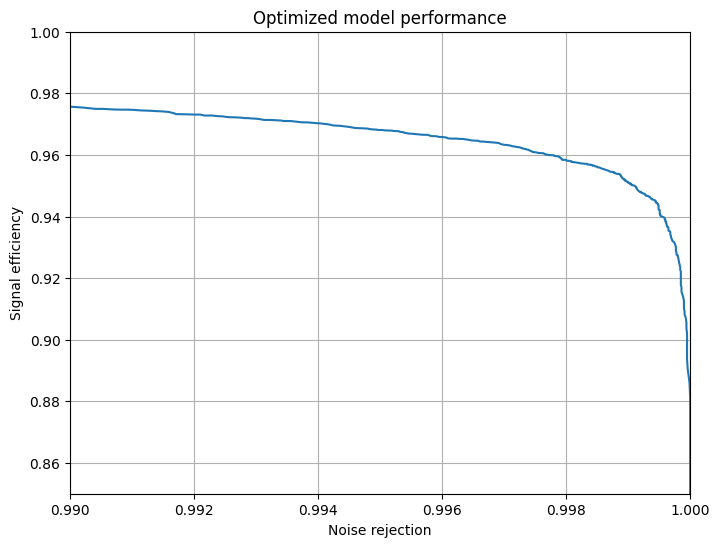

In [24]:
plt.figure(figsize=(8,6))
plt.plot(noise_rej_small, signal_eff_small)

plt.xlim(0.99, 1.0)
plt.ylim(0.85, 1.0)

plt.xlabel("Noise rejection")
plt.ylabel("Signal efficiency")
plt.title("Optimized model performance")
plt.grid()
plt.show()

###Results

The optimized neural network achieved a noise rejection rate of 99.9% while maintaining a signal efficiency of 95.1%, exceeding the assignment requirements of 99.9% noise rejection and 90% signal efficiency.

The computational complexity of the optimized model was reduced to 3497 floating point operations (FLOPS), significantly lowering the computational cost while preserving detector performance.

Therefore, the detector sensitivity goal was achieved with a substantially smaller neural network.